<a href="https://colab.research.google.com/github/sirishan506-source/google-collab/blob/main/IPL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [ ]:
df = pd.read_csv("IPL IMB381IPL2013.csv")

print(df.head())

   Sl.NO.   PLAYER NAME  AGE COUNTRY  TEAM PLAYING ROLE  T-RUNS  T-WKTS  \
0       1   Abdulla, YA    2      SA  KXIP   Allrounder       0       0   
1       2  Abdur Razzak    2     BAN   RCB       Bowler     214      18   
2       3   Agarkar, AB    2     IND   KKR       Bowler     571      58   
3       4     Ashwin, R    1     IND   CSK       Bowler     284      31   
4       5  Badrinath, S    2     IND   CSK      Batsman      63       0   

   ODI-RUNS-S  ODI-SR-B  ...    SR-B  SIXERS  RUNS-C  WKTS  AVE-BL   ECON  \
0           0      0.00  ...    0.00       0     307    15   20.47   8.90   
1         657     71.41  ...    0.00       0      29     0    0.00  14.50   
2        1269     80.62  ...  121.01       5    1059    29   36.52   8.81   
3         241     84.56  ...   76.32       0    1125    49   22.96   6.23   
4          79     45.93  ...  120.71      28       0     0    0.00   0.00   

   SR-BL  AUCTION YEAR  BASE PRICE  SOLD PRICE  
0  13.93          2009       50000   

In [ ]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sl.NO.         130 non-null    int64  
 1   PLAYER NAME    130 non-null    object 
 2   AGE            130 non-null    int64  
 3   COUNTRY        130 non-null    object 
 4   TEAM           130 non-null    object 
 5   PLAYING ROLE   130 non-null    object 
 6   T-RUNS         130 non-null    int64  
 7   T-WKTS         130 non-null    int64  
 8   ODI-RUNS-S     130 non-null    int64  
 9   ODI-SR-B       130 non-null    float64
 10  ODI-WKTS       130 non-null    int64  
 11  ODI-SR-BL      130 non-null    float64
 12  CAPTAINCY EXP  130 non-null    int64  
 13  RUNS-S         130 non-null    int64  
 14  HS             130 non-null    int64  
 15  AVE            130 non-null    float64
 16  SR-B           130 non-null    float64
 17  SIXERS         130 non-null    int64  
 18  RUNS-C    

In [ ]:
numeric_df = df.select_dtypes(include=['int64','float64'])

print(numeric_df.columns)

Index(['Sl.NO.', 'AGE', 'T-RUNS', 'T-WKTS', 'ODI-RUNS-S', 'ODI-SR-B',
       'ODI-WKTS', 'ODI-SR-BL', 'CAPTAINCY EXP', 'RUNS-S', 'HS', 'AVE', 'SR-B',
       'SIXERS', 'RUNS-C', 'WKTS', 'AVE-BL', 'ECON', 'SR-BL', 'AUCTION YEAR',
       'BASE PRICE', 'SOLD PRICE'],
      dtype='object')


In [ ]:
corr_matrix = numeric_df.corr()

print(corr_matrix)

                 Sl.NO.       AGE    T-RUNS    T-WKTS  ODI-RUNS-S  ODI-SR-B  \
Sl.NO.         1.000000 -0.064235 -0.091722  0.121835   -0.059029  0.042439   
AGE           -0.064235  1.000000  0.469402  0.293473    0.403131  0.038531   
T-RUNS        -0.091722  0.469402  1.000000  0.026285    0.892823  0.231411   
T-WKTS         0.121835  0.293473  0.026285  1.000000   -0.088276  0.012052   
ODI-RUNS-S    -0.059029  0.403131  0.892823 -0.088276    1.000000  0.319264   
ODI-SR-B       0.042439  0.038531  0.231411  0.012052    0.319264  1.000000   
ODI-WKTS       0.098777  0.306949  0.045505  0.822940    0.056554  0.160114   
ODI-SR-BL      0.084678 -0.093574  0.067700  0.060641    0.126795  0.284584   
CAPTAINCY EXP -0.096388  0.323228  0.690647  0.088782    0.714058  0.291373   
RUNS-S        -0.082366  0.002776  0.410143 -0.218544    0.523955  0.306338   
HS            -0.051490  0.083028  0.411209 -0.268432    0.495765  0.360086   
AVE           -0.108076  0.057569  0.374046 -0.26554

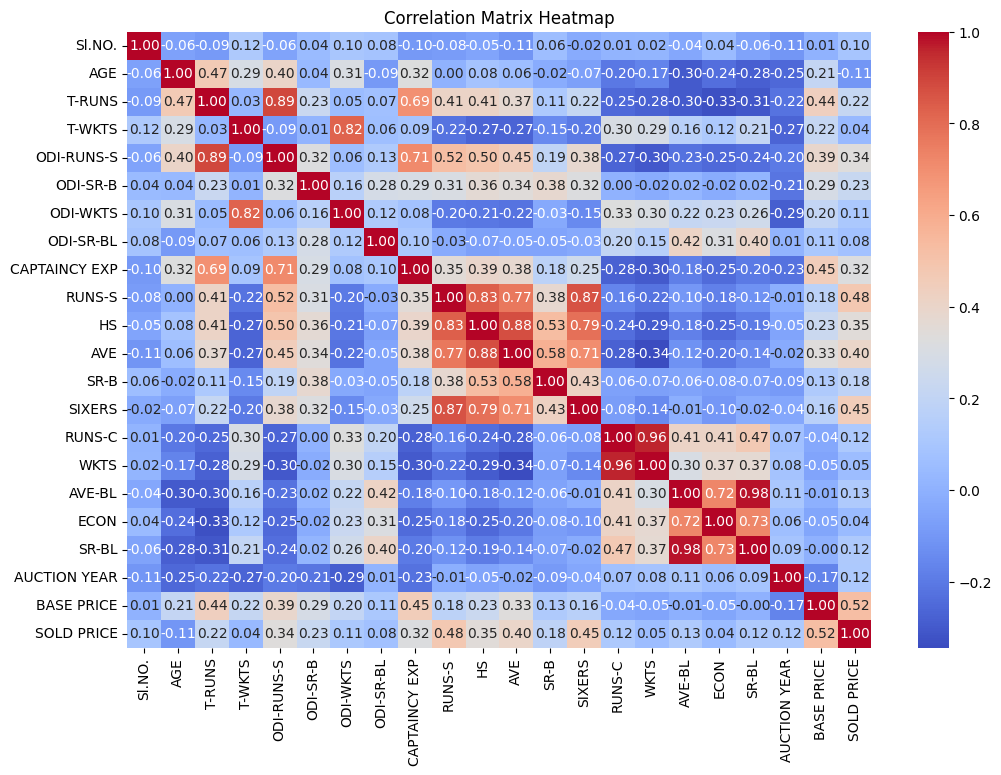

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',fmt=".2f")

plt.title("Correlation Matrix Heatmap")
plt.show()

In [ ]:

numeric_df = df.select_dtypes(include=['int64', 'float64'])

X = numeric_df.drop("SOLD PRICE", axis=1)
y = numeric_df["SOLD PRICE"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
train_pred = model.predict(X_train)

In [ ]:
test_pred = model.predict(X_test)

In [ ]:
train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))

print("Train RMSE:", train_rmse)

Train RMSE: 246632.9281741846


In [ ]:
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

print("Test RMSE:", test_rmse)


Test RMSE: 269568.3866967148


In [ ]:
coefficients = pd.DataFrame({
      "Feature": X.columns,
          "Coefficient": model.coef_
          })

print(coefficients)

          Feature    Coefficient
0          Sl.NO.    1166.945854
1             AGE  -68037.780336
2          T-RUNS     -45.120282
3          T-WKTS    -538.865498
4      ODI-RUNS-S      35.702470
5        ODI-SR-B    -386.424260
6        ODI-WKTS     872.488384
7       ODI-SR-BL    -861.776772
8   CAPTAINCY EXP  122355.280672
9          RUNS-S     342.631326
10             HS   -4436.910191
11            AVE    8396.037635
12           SR-B    -606.726909
13         SIXERS    1201.850267
14         RUNS-C     167.043927
15           WKTS    -619.773250
16         AVE-BL    4298.082832
17           ECON   -7467.412383
18          SR-BL   -4551.886308
19   AUCTION YEAR   64807.631964
20     BASE PRICE       1.293513


In [ ]:
print("Intercept:", model.intercept_)

Intercept: -129982945.40125129


   Sl.NO.   PLAYER NAME  AGE COUNTRY  TEAM PLAYING ROLE  T-RUNS  T-WKTS  \
0       1   Abdulla, YA    2      SA  KXIP   Allrounder       0       0   
1       2  Abdur Razzak    2     BAN   RCB       Bowler     214      18   
2       3   Agarkar, AB    2     IND   KKR       Bowler     571      58   
3       4     Ashwin, R    1     IND   CSK       Bowler     284      31   
4       5  Badrinath, S    2     IND   CSK      Batsman      63       0   

   ODI-RUNS-S  ODI-SR-B  ...    SR-B  SIXERS  RUNS-C  WKTS  AVE-BL   ECON  \
0           0      0.00  ...    0.00       0     307    15   20.47   8.90   
1         657     71.41  ...    0.00       0      29     0    0.00  14.50   
2        1269     80.62  ...  121.01       5    1059    29   36.52   8.81   
3         241     84.56  ...   76.32       0    1125    49   22.96   6.23   
4          79     45.93  ...  120.71      28       0     0    0.00   0.00   

   SR-BL  AUCTION YEAR  BASE PRICE  SOLD PRICE  
0  13.93          2009       50000   

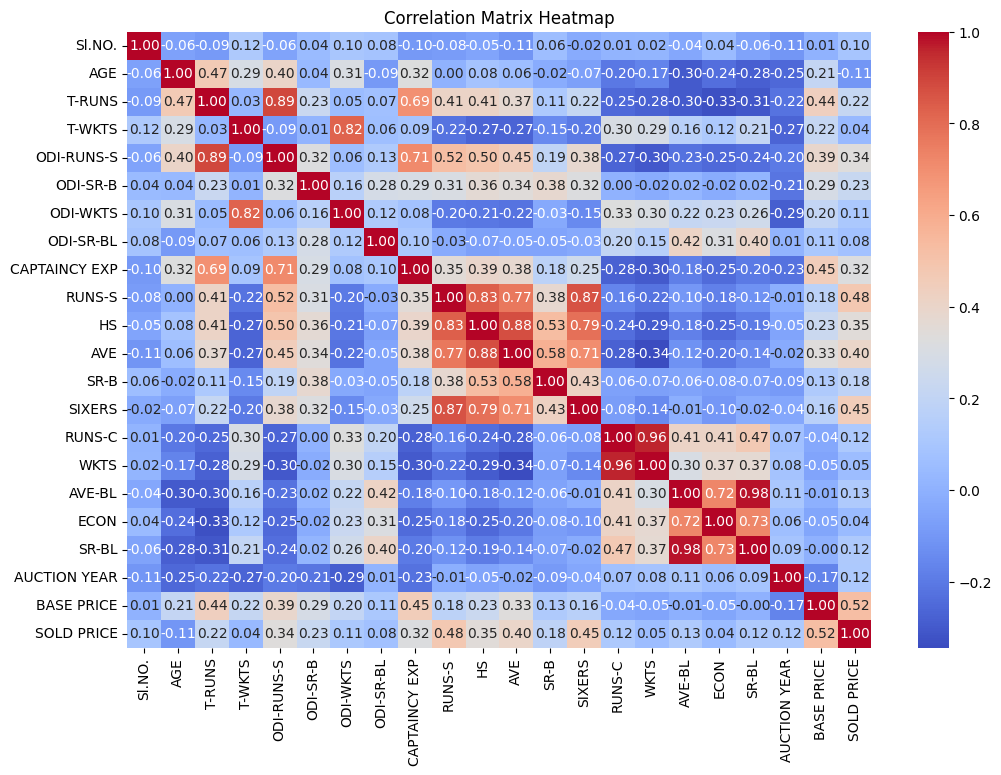

Train RMSE: 246632.9281741846
Test RMSE: 269568.3866967148
          Feature    Coefficient
0          Sl.NO.    1166.945854
1             AGE  -68037.780336
2          T-RUNS     -45.120282
3          T-WKTS    -538.865498
4      ODI-RUNS-S      35.702470
5        ODI-SR-B    -386.424260
6        ODI-WKTS     872.488384
7       ODI-SR-BL    -861.776772
8   CAPTAINCY EXP  122355.280672
9          RUNS-S     342.631326
10             HS   -4436.910191
11            AVE    8396.037635
12           SR-B    -606.726909
13         SIXERS    1201.850267
14         RUNS-C     167.043927
15           WKTS    -619.773250
16         AVE-BL    4298.082832
17           ECON   -7467.412383
18          SR-BL   -4551.886308
19   AUCTION YEAR   64807.631964
20     BASE PRICE       1.293513


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

df = pd.read_csv("IPL IMB381IPL2013.csv")

print(df.head())
print(df.info())

numeric_df = df.select_dtypes(include=['int64','float64'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix,
            annot=True,
                        cmap='coolwarm',
                                    fmt=".2f")
plt.title("Correlation Matrix Heatmap")
plt.show()

X = numeric_df.drop("SOLD PRICE", axis=1)
y = numeric_df["SOLD PRICE"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
model = LinearRegression()

model.fit(X_train, y_train)

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, test_pred))

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)
coefficients = pd.DataFrame({"Feature": X.columns,"Coefficient": model.coef_})

print(coefficients)